In [1]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error,r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv(r"E:\ML Dataset\ai4i2020.csv")

In [3]:
data

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
data.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
# deleting uid column
data = data.drop(columns="UDI")

In [7]:
data

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [8]:
# setting faeture and target
x = data.drop(columns="Machine failure")
y = data["Machine failure"]

In [9]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
print("Train Size :",x_train.shape)
print("Test Size :",x_test.shape)

Train Size : (7000, 12)
Test Size : (3000, 12)


In [10]:
# identifying numerical and categorical column
num_cols = data.select_dtypes(include=["int","float"]).drop(columns="Machine failure").columns.tolist()
cat_cols = data.select_dtypes(include="object").columns.tolist()

print("Numerical Features :", num_cols)
print("Categorical Features :", cat_cols)

Numerical Features : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Categorical Features : ['Product ID', 'Type']


In [11]:
# creating preprocessor pipeline
num_transformer = Pipeline(steps=[
    ("scaler",StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ("onehot",OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num",num_transformer,num_cols),
    ("cat",cat_transformer,cat_cols)
])

In [12]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [13]:
# creating baseline model
base_model = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("svr",SVR())
])
base_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [14]:
# predict and evaluate model
y_pred = base_model.predict(x_test)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Model Evaluation")
print("Root Mean Squared Error :", round(rmse,4))
print("R2 Score :", round(r2,4))

Model Evaluation
Root Mean Squared Error : 0.0502
R2 Score : 0.9161


In [15]:
# model hupertuning
parm_grid = {
    "svr__C" : [1,3,5,7,10,30,50,75],
    "svr__kernel" : ["linear","rbf","poly","sigmoid"],
    "svr__gamma" : [None,"auto","scale"],
    "svr__max_iter" : [-1,1000,2000,3000]
}

grid = GridSearchCV(base_model,param_grid=parm_grid,scoring="r2",cv=3,n_jobs=-1)
grid.fit(x_train,y_train)

print("Best Parameter :", grid.best_params_)
print("Best Score :", grid.best_score_)

Best Parameter : {'svr__C': 1, 'svr__gamma': 'scale', 'svr__kernel': 'rbf', 'svr__max_iter': -1}
Best Score : 0.9305788565327058


In [16]:
# evaluating best model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(x_test)
rmse_best = root_mean_squared_error(y_test,y_pred_best)
r2_best = r2_score(y_test,y_pred_best)

print("Model Evaluation(Best Model)")
print("Root Mean Squared Error :", round(rmse_best,4))
print("R2 Score :", round(r2_best,4))

Model Evaluation(Best Model)
Root Mean Squared Error : 0.0502
R2 Score : 0.9161


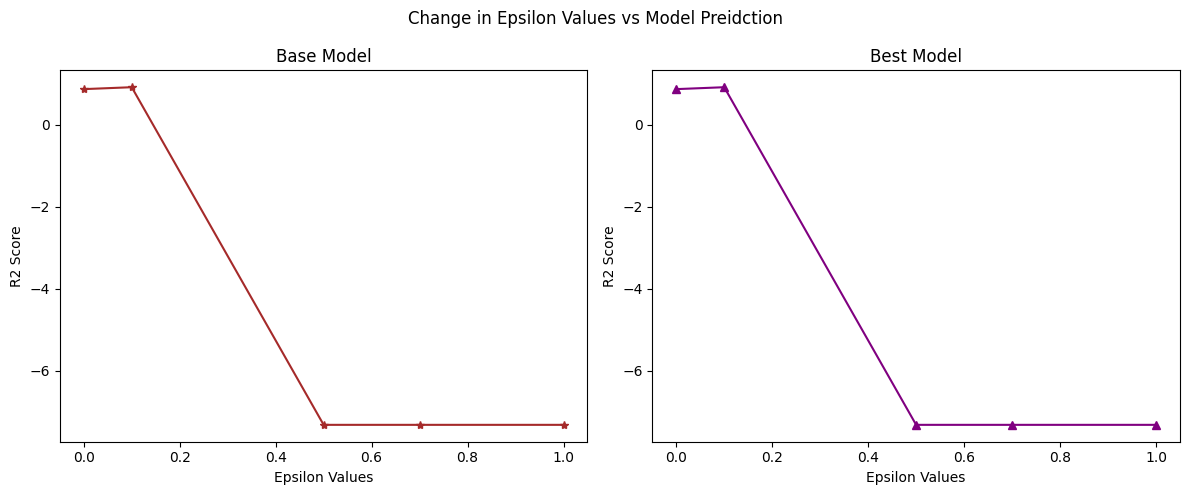

In [17]:
# plot epsilon values vs model prediction
epsilon = [0,0.1,0.5,0.7,1]
test_r2 = []
test_r2_best = []
for e in epsilon:
    base_model.set_params(svr__epsilon=e)
    best_model.set_params(svr__epsilon=e)
    base_model.fit(x_train,y_train)
    best_model.fit(x_train,y_train)
    base_pred = base_model.predict(x_test)
    best_pred = best_model.predict(x_test)
    test_r2.append(r2_score(y_test,base_pred))
    test_r2_best.append(r2_score(y_test,best_pred))

fig,axes = plt.subplots(1,2,figsize=(12,5))
axes[0].plot(epsilon,test_r2,marker="*",color="brown")
axes[0].set_ylabel("R2 Score")
axes[0].set_xlabel("Epsilon Values")
axes[0].set_title("Base Model")

axes[1].plot(epsilon,test_r2_best,marker="^",color="purple")
axes[1].set_ylabel("R2 Score")
axes[1].set_xlabel("Epsilon Values")
axes[1].set_title("Best Model")

plt.suptitle("Change in Epsilon Values vs Model Preidction")
plt.tight_layout()
plt.show()

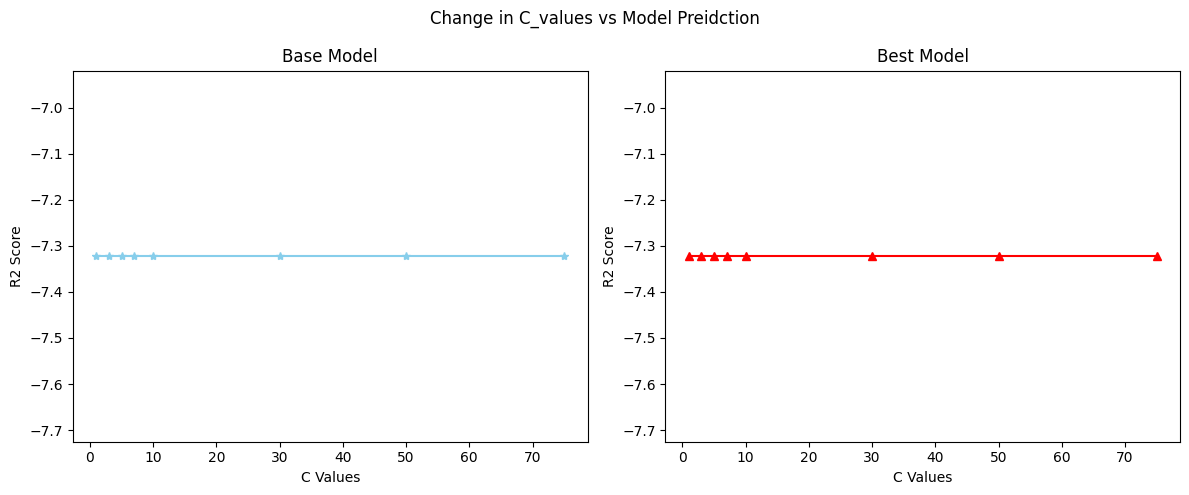

In [18]:
# plot c_values vs model prediction
c_values = [1,3,5,7,10,30,50,75]
test_r2 = []
test_r2_best = []
for c in c_values:
    base_model.set_params(svr__C=c)
    best_model.set_params(svr__C=c)
    base_model.fit(x_train,y_train)
    best_model.fit(x_train,y_train)
    base_pred = base_model.predict(x_test)
    best_pred = best_model.predict(x_test)
    test_r2.append(r2_score(y_test,base_pred))
    test_r2_best.append(r2_score(y_test,best_pred))

fig,axes = plt.subplots(1,2,figsize=(12,5))
axes[0].plot(c_values,test_r2,marker="*",color="skyblue")
axes[0].set_ylabel("R2 Score")
axes[0].set_xlabel("C Values")
axes[0].set_title("Base Model")

axes[1].plot(c_values,test_r2_best,marker="^",color="red")
axes[1].set_ylabel("R2 Score")
axes[1].set_xlabel("C Values")
axes[1].set_title("Best Model")

plt.suptitle("Change in C_values vs Model Preidction")
plt.tight_layout()
plt.show()